In [1]:
import requests
import json
import time
import os
from datetime import datetime
from typing import List, Dict, Optional, Tuple
from urllib.parse import urlparse
from pathlib import Path
import pandas as pd
import re
from tqdm import tqdm
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob


# Without search

In [2]:
def read_all_results(result_dir="./results", num_runs=20):
    """
    Read all result files from multiple runs and extract data.
    
    Returns:
        Dictionary with run numbers as keys, each containing a list of result dictionaries:
        {
            0: [list of results from run 0],
            1: [list of results from run 1],
            ...
        }
        
        Each result dictionary contains:
        - source_node: source gene (from JSON data)
        - target_node: target gene (from JSON data)
        - file_path: path to the JSON file
        - data: the JSON content
    """
    all_runs = {}
    
    for run in range(num_runs):
        run_dir = Path(result_dir) / f"negative_edges_run_{run}"
        
        # Find all JSON files in this run directory
        json_files = glob.glob(str(run_dir / "gene_regulation_result_*_no_search.json"))
        
        run_results = []
        for json_file in json_files:
            try:
                # Read the JSON file
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # Store the result
                result_entry = {
                    'source_node': data.get('source_gene'),
                    'target_node': data.get('target_gene'),
                    'file_path': json_file,
                    'data': data
                }
                run_results.append(result_entry)
                
            except Exception as e:
                print(f"Error processing {json_file}: {e}")
        
        all_runs[run] = run_results
    
    return all_runs

# Load all runs
runs = read_all_results(result_dir="./results", num_runs=15)

In [3]:
no_search_results = {}
for i in range(len(runs)):
    run = runs[i]
    for result in run:
        source = result['source_node']
        target = result['target_node']
        answer = result['data']['answer']
        if answer == False:
            p = result['data']['probability']
        elif answer == True:
            p = 0.0
        else:
            p = None
        no_search_result = no_search_results.get((source, target), [])
        no_search_result.append(p)
        no_search_results[(source, target)] = no_search_result


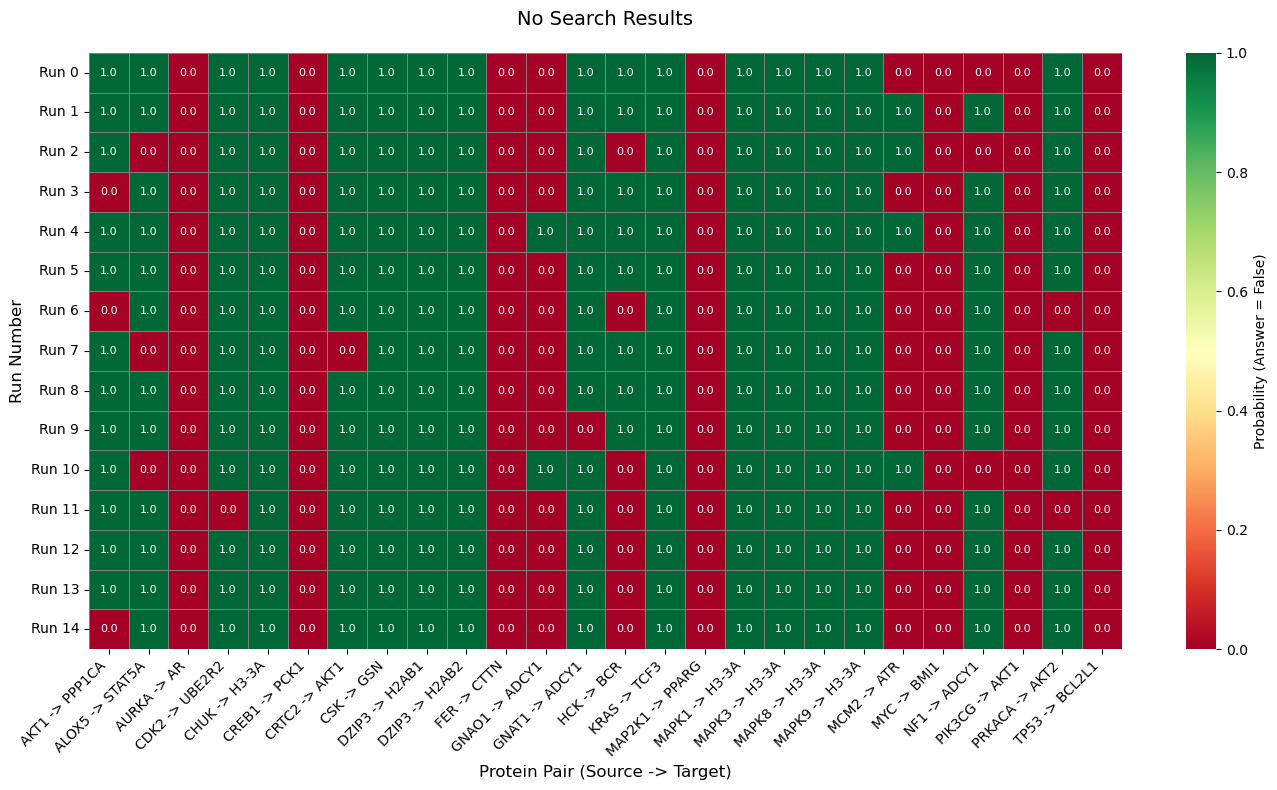

In [4]:
# Convert no_search_results to a DataFrame for heatmap
gene_pairs = list(no_search_results.keys())

# Sort gene pairs alphabetically
gene_pairs = sorted(gene_pairs, key=lambda x: (x[0], x[1]))

gene_pair_labels = [f"{source} -> {target}" for source, target in gene_pairs]
probabilities_no_search = np.array([no_search_results[pair] for pair in gene_pairs])

# Create figure
plt.figure(figsize=(14, 8))

# Create heatmap (transposed) with annotations
sns.heatmap(probabilities_no_search.T,
            xticklabels=gene_pair_labels,
            yticklabels=[f"Run {i}" for i in range(probabilities_no_search.shape[1])],
            cmap='RdYlGn',  # Green for high probability (p=1 is good), Red for low (p=0 is bad)
            vmin=0, vmax=1,
            cbar_kws={'label': 'Probability (Answer = False)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,  # Add numbers to blocks
            fmt='.1f',  # Format numbers to 2 decimal places
            annot_kws={'fontsize': 8})  # Adjust font size for readability

plt.title('No Search Results', fontsize=14, pad=20)
plt.xlabel('Protein Pair (Source -> Target)', fontsize=12)
plt.ylabel('Run Number', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('no_search_results_heatmap.png')
plt.show()

In [5]:
# Accuracy
acc = np.sum(probabilities_no_search>0.5)/probabilities_no_search.size
print(f"Accuracy without search: {acc:.2f}")

Accuracy without search: 0.62


## Plot the distance between the answer and the wrong answer

In [6]:
no_search_distances = {}
wrong_answers = ['Yes', 'yes', 'YES', 'True', 'true', 'TRUE']
for i in range(len(runs)):
    run = runs[i]
    for result in run:
        source = result['source_node']
        target = result['target_node']
        answer = result['data']['answer']
        logprob = result['data']['logprob']
        
        if answer == False:
            # Find the first wrong answer alternative and calculate distance
            distance = np.nan
            for alt in result['data']['alternatives']:
                if alt['token'] in wrong_answers:
                    alt_logprob = alt['logprob']
                    distance = logprob - alt_logprob
                    break  # Stop after finding the first wrong answer
        else:
            distance = np.nan
        
        # Append to the list for this gene pair
        distance_list = no_search_distances.get((source, target), [])
        distance_list.append(distance)
        no_search_distances[(source, target)] = distance_list

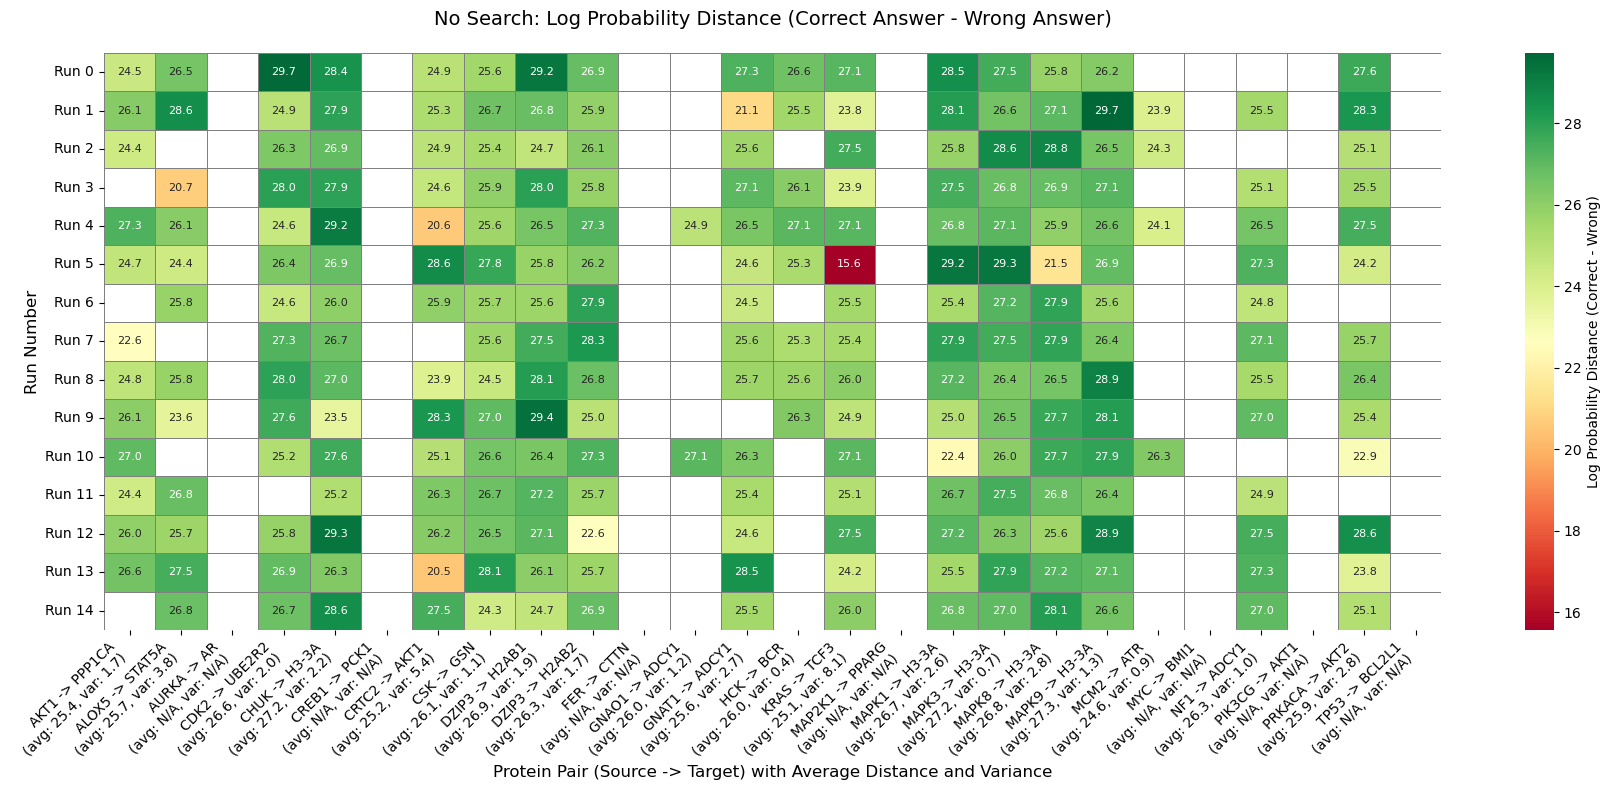

In [7]:
# Convert no_search_distances to a DataFrame for heatmap
gene_pairs = list(no_search_distances.keys())

# Sort gene pairs alphabetically
gene_pairs = sorted(gene_pairs, key=lambda x: (x[0], x[1]))

gene_pair_labels = [f"{source} -> {target}" for source, target in gene_pairs]
distances_no_search = np.array([no_search_distances[pair] for pair in gene_pairs])

# Calculate average distance and variance for each gene pair
avg_distances = []
var_distances = []
for gene_pair in gene_pairs:
    distances = no_search_distances[gene_pair]
    valid_distances = [d for d in distances if not np.isnan(d)]
    if valid_distances:
        avg_distances.append(np.mean(valid_distances))
        var_distances.append(np.var(valid_distances))
    else:
        avg_distances.append(np.nan)
        var_distances.append(np.nan)

# Create gene pair labels with average distance and variance
gene_pair_labels_with_stats = [
    f"{source} -> {target}\n(avg: {avg:.1f}, var: {var:.1f})" if not np.isnan(avg) else f"{source} -> {target}\n(avg: N/A, var: N/A)"
    for (source, target), avg, var in zip(gene_pairs, avg_distances, var_distances)
]

# Create figure
plt.figure(figsize=(18, 8))

# Create heatmap (transposed) with annotations
# Higher distance = more confident in correct answer (larger gap between correct and wrong logprob)
sns.heatmap(distances_no_search.T,
            xticklabels=gene_pair_labels_with_stats,
            yticklabels=[f"Run {i}" for i in range(distances_no_search.shape[1])],
            cmap='RdYlGn',  # Green for high distance (confident), Red for low (uncertain)
            cbar_kws={'label': 'Log Probability Distance (Correct - Wrong)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,  # Add numbers to blocks
            fmt='.1f',  # Format numbers to 1 decimal place
            annot_kws={'fontsize': 8})  # Adjust font size for readability

plt.title('No Search: Log Probability Distance (Correct Answer - Wrong Answer)', 
          fontsize=14, pad=20)
plt.xlabel('Protein Pair (Source -> Target) with Average Distance and Variance', fontsize=12)
plt.ylabel('Run Number', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('no_search_distances_heatmap.png')
plt.show()

In [8]:
from scipy import stats

In [9]:
# plt.hist(avg_distances, bins=10)
# Test if avg_distances follows normal distribution
stats.normaltest(avg_distances)
print(f'Variance of different question: {np.nanvar(avg_distances):.2f}')
# NOTE: It turns out the variance within protein pair are generally higher than the variance between the average values. This means that the differences of the same question but different runs are more variable than the differences between questions, i.e. this means it is pure noise.

Variance of different question: 0.54


In [10]:
# # Print average distance for each gene pair
# print("Average Distance (Correct - Wrong Answer) for Each Gene Pair:\n")
# print(f"{'Gene Pair':<30} {'Average Distance':>20}")
# print("=" * 55)

# for gene_pair in gene_pairs:
#     distances = no_search_distances[gene_pair]
#     # Calculate mean ignoring NaN values
#     valid_distances = [d for d in distances if not np.isnan(d)]
#     if valid_distances:
#         avg_distance = np.mean(valid_distances)
#         source, target = gene_pair
#         pair_label = f"{source} -> {target}"
#         print(f"{pair_label:<30} {avg_distance:>20.2f}")
#     else:
#         source, target = gene_pair
#         pair_label = f"{source} -> {target}"
#         print(f"{pair_label:<30} {'N/A':>20}")

# # Overall average
# all_valid_distances = []
# for gene_pair in gene_pairs:
#     distances = no_search_distances[gene_pair]
#     all_valid_distances.extend([d for d in distances if not np.isnan(d)])

# if all_valid_distances:
#     overall_avg = np.mean(all_valid_distances)
#     print("=" * 55)
#     print(f"{'Overall Average':<30} {overall_avg:>20.2f}")

# With search

In [11]:
def read_all_results(result_dir="./results", num_runs=20):
    """
    Read all result files from multiple runs and extract data.
    
    Returns:
        Dictionary with run numbers as keys, each containing a list of result dictionaries:
        {
            0: [list of results from run 0],
            1: [list of results from run 1],
            ...
        }
        
        Each result dictionary contains:
        - source_node: source gene (from JSON data)
        - target_node: target gene (from JSON data)
        - file_path: path to the JSON file
        - data: the JSON content
    """
    all_runs = {}
    
    for run in range(num_runs):
        run_dir = Path(result_dir) / f"negative_edges_run_{run}"
        
        # Find all JSON files in this run directory
        json_files = glob.glob(str(run_dir / "gene_regulation_result_*_with_search.json"))
        
        run_results = []
        for json_file in json_files:
            try:
                # Read the JSON file
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # Store the result
                result_entry = {
                    'source_node': data.get('source_gene'),
                    'target_node': data.get('target_gene'),
                    'file_path': json_file,
                    'data': data
                }
                run_results.append(result_entry)
                
            except Exception as e:
                print(f"Error processing {json_file}: {e}")
        
        all_runs[run] = run_results
    
    return all_runs

# Load all runs
runs = read_all_results(result_dir="./results", num_runs=14)

In [12]:
with_search_results = {}
for i in range(len(runs)):
    run = runs[i]
    for result in run:
        source = result['source_node']
        target = result['target_node']
        answer = result['data']['answer']
        if answer == False:
            p = result['data']['probability']
        elif answer == True:
            p = 0.0
        else:
            p = None
        with_search_result = with_search_results.get((source, target), [])
        with_search_result.append(p)
        with_search_results[(source, target)] = with_search_result


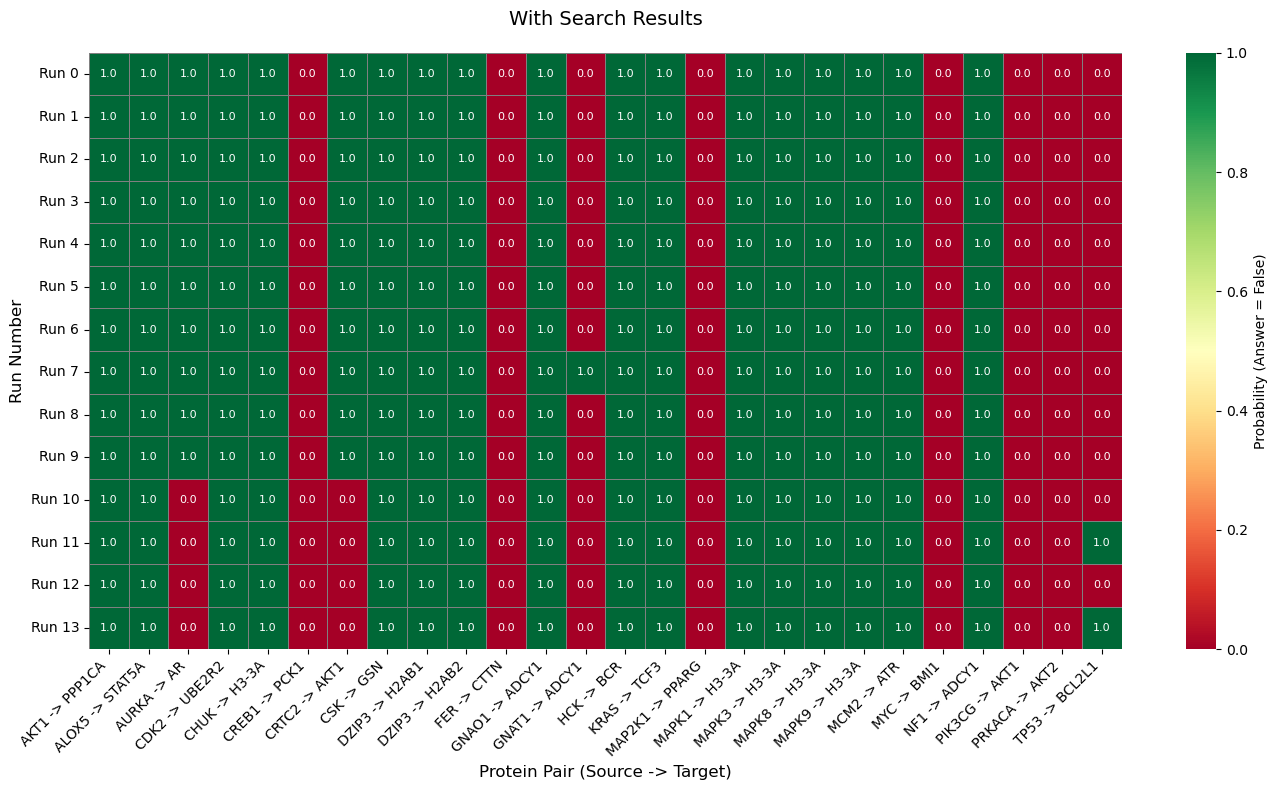

In [13]:
# Convert with_search_results to a DataFrame for heatmap
gene_pairs = list(with_search_results.keys())

# Sort gene pairs alphabetically
gene_pairs = sorted(gene_pairs, key=lambda x: (x[0], x[1]))

gene_pair_labels = [f"{source} -> {target}" for source, target in gene_pairs]
probabilities_with_search = np.array([with_search_results[pair] for pair in gene_pairs])

# Create figure
plt.figure(figsize=(14, 8))

# Create heatmap (transposed) with annotations
sns.heatmap(probabilities_with_search.T,
            xticklabels=gene_pair_labels,
            yticklabels=[f"Run {i}" for i in range(probabilities_with_search.shape[1])],
            cmap='RdYlGn',  # Green for high probability (p=1 is good), Red for low (p=0 is bad)
            vmin=0, vmax=1,
            cbar_kws={'label': 'Probability (Answer = False)'},
            linewidths=0.5,
            linecolor='gray',
            annot=True,  # Add numbers to blocks
            fmt='.1f',  # Format numbers to 2 decimal places
            annot_kws={'fontsize': 8})  # Adjust font size for readability

plt.title('With Search Results', fontsize=14, pad=20)
plt.xlabel('Protein Pair (Source -> Target)', fontsize=12)
plt.ylabel('Run Number', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('with_search_results_heatmap.png')
plt.show()

In [14]:
# Accuracy
acc = np.sum(probabilities_with_search>0.5)/probabilities_with_search.size
print(f"Accuracy with search: {acc:.2f}")

Accuracy with search: 0.68


# Difference (With Search - Without Search)

In [15]:
# # Calculate the difference: with_search - no_search
# # Positive values mean search improved the probability
# # Negative values mean search decreased the probability
# probability_difference = probabilities_with_search - probabilities_no_search

# # Create figure
# plt.figure(figsize=(14, 8))

# # Create heatmap (transposed) with annotations
# # Use RdBu_r colormap: Red for negative (worse with search), Blue for positive (better with search)
# sns.heatmap(probability_difference.T,
#             xticklabels=gene_pair_labels,
#             yticklabels=[f"Run {i}" for i in range(probability_difference.shape[1])],
#             cmap='RdYlGn',  # Blue for positive (improvement), Red for negative (degradation)
#             center=0,  # Center the colormap at 0
#             vmin=-1, vmax=1,
#             cbar_kws={'label': 'Probability Difference (With Search - No Search)'},
#             linewidths=0.5,
#             linecolor='gray',
#             annot=True,  # Add numbers to blocks
#             fmt='.2f',  # Format numbers to 2 decimal places
#             annot_kws={'fontsize': 8})  # Adjust font size for readability

# plt.title('Difference: With Search - Without Search\n(Green = Improvement, Red = Degradation)', 
#           fontsize=14, pad=20)
# plt.xlabel('Protein Pair (Source -> Target)', fontsize=12)
# plt.ylabel('Run Number', fontsize=12)
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()

# plt.savefig('probability_difference_heatmap.png')
# plt.show()

# Plot the token logprobs

In [1]:
# Load a single JSON file and visualize token logprobs
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import json
from IPython.display import HTML, display

# Load the JSON file
file_path = 'llm_response_CSK_GSN.json'
with open(file_path, 'r') as f:
    data = json.load(f)

# Extract tokens and logprobs
tokens = []
logprobs = []

for item in data['completion_probabilities']:
    tokens.append(item['token'])
    logprobs.append(item['logprob'])

# Convert to numpy array
logprobs = np.array(logprobs)

# Convert logprobs to probabilities (no normalization needed!)
probabilities = np.exp(logprobs)

print(f"Total tokens: {len(tokens)}")
print(f"Logprob range: [{logprobs.min():.2f}, {logprobs.max():.2f}]")
print(f"Probability range: [{probabilities.min():.4f}, {probabilities.max():.4f}]")

# Create a colormap - higher probability = lighter color
cmap = plt.cm.RdYlGn

# Create HTML visualization with colored tokens
html_parts = ['<div style="font-family: monospace; font-size: 14px; line-height: 1.8; padding: 20px; background-color: #f5f5f5;">']

for i, (token, logprob, prob) in enumerate(zip(tokens, logprobs, probabilities)):
    # Get color for this probability (prob is already in [0, 1])
    rgba = cmap(prob)
    rgb_hex = '#{:02x}{:02x}{:02x}'.format(int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))
    
    # Escape HTML special characters
    token_escaped = token.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;').replace(' ', '&nbsp;')
    
    # Add colored span for each token
    html_parts.append(f'<span style="background-color: {rgb_hex}; padding: 2px 1px;" title="probability: {prob:.4f}, logprob: {logprob:.4f}">{token_escaped}</span>')

html_parts.append('</div>')

# Display the HTML
html_output = ''.join(html_parts)
display(HTML(html_output))
# save the HTML output to a file
with open('llm_response_CSK_GSN.html', 'w') as f:
    f.write(html_output)

# # Also create a matplotlib figure with colorbar legend
# fig, ax = plt.subplots(figsize=(10, 1))
# fig.subplots_adjust(bottom=0.5)

# norm = Normalize(vmin=0, vmax=1)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])

# cbar = plt.colorbar(sm, cax=ax, orientation='horizontal')
# cbar.set_label('Probability (Higher = More Confident)', fontsize=12)
# ax.set_title('Color Scale: Lighter = Higher Probability (More Confident)', fontsize=10, pad=10)

# plt.tight_layout()

# plt.show()

# NOTE: The second Yes in "So answer Yes" has a lower probability (logprob -0.083 (p=0.92)). But the alternatives are all Yes or some other notations.
# There is no other No answer. So, it doesn't really show how confident the LLM is.

Total tokens: 451
Logprob range: [-4.44, 0.00]
Probability range: [0.0118, 1.0000]


In [2]:
import numpy as np

In [4]:
np.exp(-0.5284366607666016)

np.float64(0.5895258785793737)